In [18]:
import numpy as np
import json
import pylab as plt
import pdb
import math
import os
from jlu.observe import skycalc
from microlens.jlu import munge 
from microlens.jlu import model_fitter, model
import shutil, os, sys
import scipy
import scipy.stats
from scipy.stats import chi2
from jlu.papers import huston_2025_lens
from astropy.table import Table
from jlu.util import fileUtil
from astropy.table import Table, Column, vstack
from astropy.io import fits
import matplotlib.ticker
import matplotlib.colors
from matplotlib.pylab import cm
from matplotlib.colors import Normalize, LogNorm
import mpl_toolkits
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from matplotlib.ticker import NullFormatter
from microlens.jlu import model_fitter, multinest_utils, multinest_plot, munge_ob150211, munge_ob150029, model
from matplotlib.colors import LinearSegmentedColormap, colorConverter
import pdb
import pickle
from scipy.stats import norm
import yaml
from flystar import plots
from flystar import analysis
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from jlu.util import datetimeUtil as dtUtil
from datetime import datetime as dt

In [3]:
# Fontsize
plt.rc('font', size=17)

# Default matplotlib color cycles.
mpl_b = '#1f77b4'
mpl_o = '#ff7f0e'
mpl_g = '#2ca02c'
mpl_r = '#d62728'

In [67]:
phot_ast_fits = {'MB09260' : '/u/jlu/work/microlens/MB09260/a_2021_09_19/model_fits/moa_hst_phot_ast_gp/base_a/a0_',
                 'MB09260_split' : '/u/jlu/work/microlens/MB09260/a_2021_09_19/model_fits/moa_hst_phot_ast_gp/base_a/a0_split_',
                 'MB10364' : '/u/jlu/work/microlens/MB10364/a_2021_09_19/model_fits/moa_hst_phot_ast_adderr/base_a/a0_', # NO GP, TEMPORARY              
                 'OB110037' : '/u/jlu/work/microlens/OB110037/a_2021_07_08/model_fits/ogle_hst_phot_ast_gp/base_a/a0_',
                 'OB110310' : '/u/jlu/work/microlens/OB110310/a_2021_07_08/model_fits/ogle_hst_phot_ast_gp/base_a/a0_',
                 'OB110310_split' : '/u/jlu/work/microlens/OB110310/a_2021_07_08/model_fits/ogle_hst_phot_ast_gp/base_a/a0_split_',
                 'OB110462_el' : '/u/jlu/work/microlens/OB110462/a_2021_12_28/model_fits/ogle_hst_phot_ast/pspl/fixed_weight/a0_', # EQUAL LIKELIHOOD    
                 'OB110462_p' : '/u/jlu/work/microlens/OB110462/a_2021_07_08/model_fits/ogle_hst_phot_ast_gp/u0p_En_Nn/a0_',
                 'OB110462_new_dw_ast' : '/u/jlu/work/microlens/OB110462/a_2023_04_23/model_fits/hst_ast/base_a/a0_',
                 #'MB19284' : '/g2/scratch/jlu/microlens/MB19284/a_2024_08_29/model_fit/BSPL_base_a0_allDATA_Hobson_Weighted_noOM_dragon/a0_'
                 'MB19284' : '/u/jlu/work/microlens/MB19284/a_2025_11_11/model_fit/BSPL_base_a0_EW_OM_nersc/a0_'
                }
# From reanalysis
phot_fits = {'OB110462' : '/u/jlu/work/microlens/OB110462/a_2023_04_23/model_fits/ogle_hst_phot_gp/base_a/a0_'} # nominal fits                              
ast_fits = {'OB110462' : '/u/jlu/work/microlens/OB110462/a_2023_04_23/model_fits/hst_ast/base_a/a0_'}

mdir = '/u/jlu/work/microlens/'
phot_2020_dir = {'kb200101' : mdir + 'KB200101/a_2026_01_08/model_fit/PSPL_phot_only/a0_',
                 'MB19284' : mdir + 'MB19284/a_2025_11_11/model_fit/BSPL_base_a0_EW_OM_nersc/a0_',
                 'ob190017' : mdir + 'OB190017/a_2025_09_17/a0_',
                 'ob170019' : mdir + 'OB170019/a_2025_09_17/a2_',
                 'ob170095' : mdir + 'OB170095/a_2025_09_17/a0_',
                 'ob230215' : mdir + 'OB230215_MB23024/a_2026_03_19/model_fits/a0_',
                 'ob240062' : mdir + 'OB240062/a_2026_03_19/model_fits/a0_'}

In [31]:
# run directory
ob120169_dir = '/u/jlu/work/microlens/OB120169/a_2026_01_07/model_fits/ogle_keck/124_phot_astrom_aerr_merr/'
ob140613_dir = '/u/jlu/work/microlens/OB140613/a_2026_01_07/model_fits/perlmutter/NOOS/ogle_moa_keck/124_phot_astrom_aerr_merr/'
ob150029_dir = '/u/jlu/work/microlens/OB150029/a_2026_01_07/model_fits/perlmutter/ogle_moa_keck/124noV_phot_astrom_aerr_merr/'
ob150211_dir = '/u/jlu/work/microlens/OB150211/a_2026_01_07/model_fits/ogle_keck/123_phot_astrom_aerr/'

# run id
ob120169_id = 'a4'
ob140613_id = 'a2'
ob150029_id = 'a1'
ob150211_id = 'a0'

mod_roots = {'ob120169': ob120169_dir + ob120169_id + '_',
             'ob140613': ob140613_dir + ob140613_id + '_',
             'ob150029': ob150029_dir + ob150029_id + '_',
             'ob150211': ob150211_dir + ob150211_id + '_',
             'mb19284':  phot_ast_fits['MB19284']}

In [15]:
pspl_ast_multiphot = {'ob120169': ob120169_dir + ob120169_id + '_',
             'ob140613': ob140613_dir + ob140613_id + '_',
             'ob140613_alt': ob140613_dir + ob140613_id + '_',
             'ob150029': ob150029_dir + ob150029_id + '_',
             'ob150211': ob150211_dir + ob150211_id + '_'}
pspl_ast_multiphot_mode = {'ob120169': 0,
                           'ob140613': 0,
                           'ob140613_alt': 1,
                           'ob150029': 0,
                           'ob150211': 0}

# Airmass + moon position

In [6]:
target_data = json.load(open('/u/mhuston/code/plot-airmass/target_coords.json'))
print([target_data['all_coords'][x] for x in target_data['run_targets']['Keck_AO_2025']])

[['17:53:57.68', '-28:34:21.6'], ['18:05:55.06', '-30:20:12.94'], ['18:20:20.3777', '-21:35:14.9'], ['17:49:11.12', '-21:10:19.9']]


In [20]:
ra = "18:00:00"
dec = "-30:00:00"
months = np.array([8,8,9])
days = np.array([1,15,1])
outdir = '/u/mhuston/work/prop_keck_2026b/'

Midnight: 2026-08-15 10:00:00.000
Sunrise  6.1   Sunset -5.2  (hours around midnight HST)
12-degr -4.3  12-degr  5.2  (hours around midnight HST)


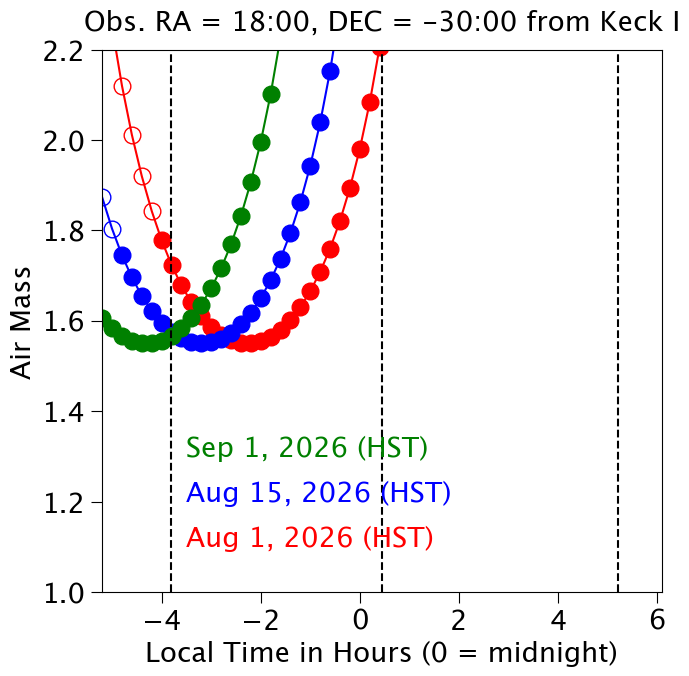

In [25]:
skycalc.plot_airmass(ra, dec, 2026, months, days, 'keck1', outfile=outdir + 'microlens_airmass_keck1_26B.png', 
                     date_idx=1, proposal_cycle = 'B')

Day:  1   Moon Illum: 92.3   Moon Dist: 69.9
Day:  2   Moon Illum: 85.9   Moon Dist: 82.6
Day:  3   Moon Illum: 77.9   Moon Dist: 95.6
Day:  4   Moon Illum: 68.3   Moon Dist: 108.8
Day:  5   Moon Illum: 57.7   Moon Dist: 122.3
Day:  6   Moon Illum: 46.5   Moon Dist: 136.1
Day:  7   Moon Illum: 35.3   Moon Dist: 150.1
Day:  8   Moon Illum: 24.6   Moon Dist: 164.4
Day:  9   Moon Illum: 15.1   Moon Dist: 177.0
Day: 10   Moon Illum:  7.6   Moon Dist: 165.6
Day: 11   Moon Illum:  2.5   Moon Dist: 150.9
Day: 12   Moon Illum:  0.2   Moon Dist: 136.2
Day: 13   Moon Illum:  0.6   Moon Dist: 121.7
Day: 14   Moon Illum:  3.7   Moon Dist: 107.5
Day: 15   Moon Illum:  9.1   Moon Dist: 93.6
Day: 16   Moon Illum: 16.2   Moon Dist: 80.2
Day: 17   Moon Illum: 24.6   Moon Dist: 67.3
Day: 18   Moon Illum: 33.8   Moon Dist: 54.7
Day: 19   Moon Illum: 43.4   Moon Dist: 42.4
Day: 20   Moon Illum: 53.0   Moon Dist: 30.3
Day: 21   Moon Illum: 62.4   Moon Dist: 18.5
Day: 22   Moon Illum: 71.3   Moon Dist:  6.7

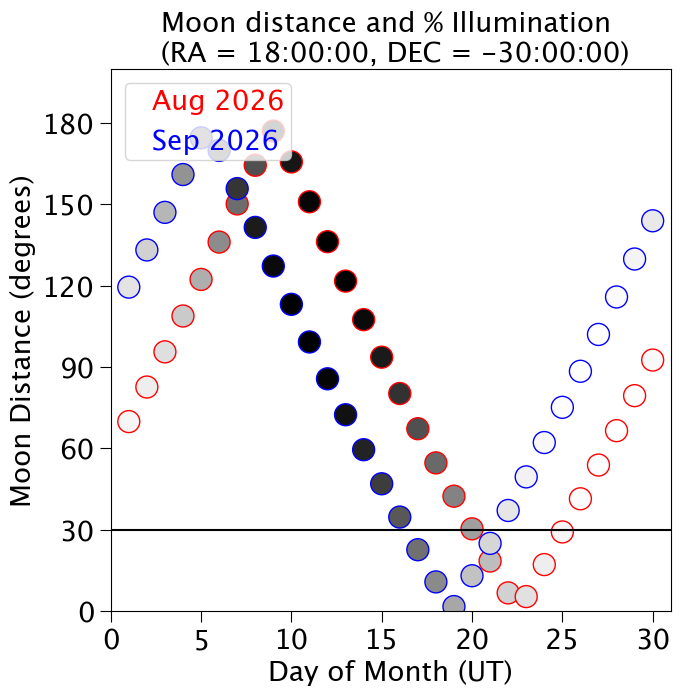

In [22]:
skycalc.plot_moon(ra, dec, 2026, [8,9], outfile=outdir + 'microlens_moon_26B.png')

 # tE piE plots

/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


***** WARNING: PHOTOMETRY DATA WILL NOT BE FIT BY <class 'bagle.model.PSPL_Astrom_Par_Param3'> *****


ob120169 178.3909805502215 0.15424644712651073 56020.309461986544
ob140613 294.68210713606095 0.15113210495397678 57192.19351099519
ob140613 294.68210713606095 0.15113210495397678
ob150029 121.66692824699746 0.14980118441292853 57246.06640664478
ob150029 121.66692824699746 0.14980118441292853
ob150211 124.22550717872723 0.03855724542901922 57212.15049831765
ob170019 135.2091970486517 0.06227405755684999 57928.34652272504
ob170019 135.2091970486517 0.06227405755684999
ob170095 105.63364685242767 0.06587231278387992 57892.19722745522
ob190017 243.97568134943612 0.29487147224277366 58604.581484277944
kb200101 98.45919261964956 0.034818459211325044 59022.45940951111
ob230215 388.33970285280043 0.1395076980046931 60005.16905096981
ob240062 191.92819312453204 0.034405414031792196 60448.52966120576
MB09260 142.9685443906927 0.09596691148210074 55099.27950805289
MB10364 61.107527351576955 0.2665760903689065 55445.12856951317
OB110037 92.80317932371783 0.37113004158553836 55781.51110912173
OB11

/u/mhuston/code/BAGLE_Microlensing/src/bagle/model_fitter.py:5791: UserWarning: The following kwargs were not used by contour: 'quantiles_2d'
  ax.contour(X2, Y2, H2.T, V, colors = color, **contour_kwargs, **kwargs)


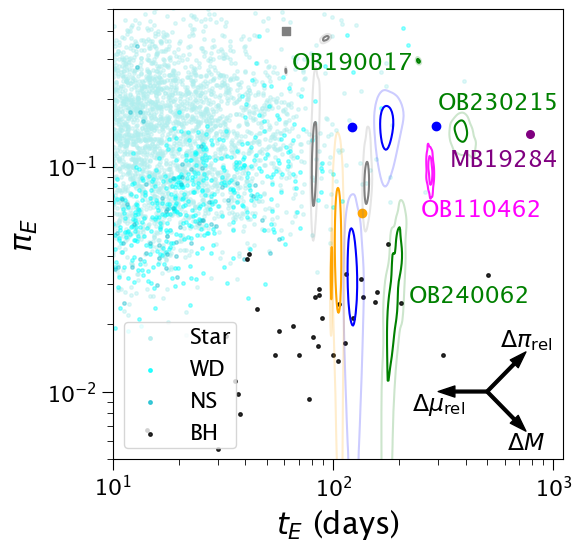

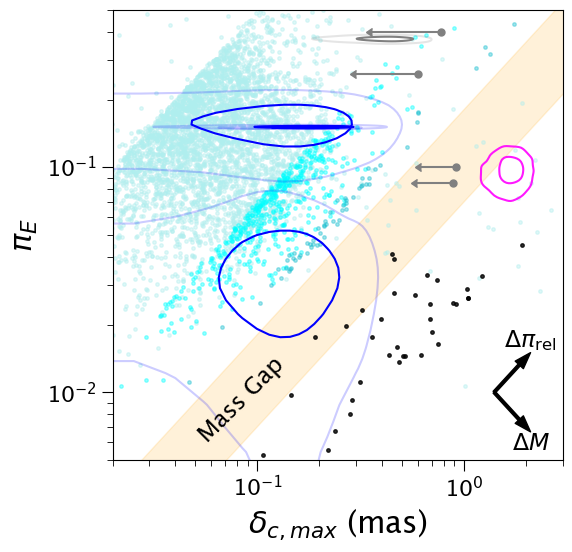

In [75]:
def piE_tE(fit_type = 'ast'):
    """
    Supports plotting for several different fit solutions:

    fit_type = 'ast'
        Keck + OGLE photometry, Keck astrometry
    fit_type = 'phot'
        OGLE photometry
    fit_type = 'multiphot'
        Keck + OGLE photometry
    """
    piE_tE_textsize = 22
    
    if fit_type == 'ast':
        data_dict = mod_roots
    if fit_type == 'phot':
        data_dict = huston_2025_lens.pspl_phot
    if fit_type == 'multiphot':
        data_dict = huston_2025_lens.pspl_multiphot

    ##########
    # !!! NOTE: CHOICE OF THE quantiles_2d HAS A LARGE EFFECT 
    # ON THE WAY THIS PLOT LOOKS !!!
    # Plot piE-tE 2D posteriors from OGLE photometry only fits.
    # Also plot PopSyCLE simulations simultaneously.
    ##########
    span = 0.999999426697
    smooth = 0.04
    quantiles_2d = None
    hist2d_kwargs = None
    labels = None
    label_kwargs = None
    show_titles = False 
    title_fmt = ".2f" 
    title_kwargs = None
    
    # Initialize values.
    if label_kwargs is None:
        label_kwargs = dict()
    if title_kwargs is None:
        title_kwargs = dict()
    if hist2d_kwargs is None:
        hist2d_kwargs = dict()

    # Dictionary of dictionaries containing the tE and piE
    # label position for each of the text labels.
    # WARNING: THE 'PHOT' AND 'AST' ARE THE SAME FOR THE NEW
    # TARGETS... THEY ARE JUST PHOT THOUGH.
    label_pos = {'phot': {'OB110462': [400, 0.15],
                          'ob120169': [150, 0.01],
                          'ob140613': [170, 0.1],
                          'ob150029': [150, 0.2],
                          'ob150211': [35, 0.04],
                          'ob170019': [0, 0.04],
                          'ob170095': [0, 0.04],
                          'ob190017': [0, 0.04],
                          'kb200101': [0, 0],
                          'ob230215': [400, 0.1],
                          'ob240062': [220, 0.03]},
                 'ast':  {'OB110462': [250, 0.06],
                          'ob120169': [45, 0.12],
                          'ob140613': [250, 0.16],
                          'ob150029': [40, 0.22],
                          'ob150211': [140, 0.01],
                          'ob170019': [120, 0.045],
                          'ob170095': [30, 0.04],
                          'ob190017': [65, 0.27],
                          'kb200101': [180, 0.016],
                          'MB19284' : [340, 0.1],
                          'ob230215': [300, 0.18],
                          'ob240062': [220, 0.025]}}

    label_pos_ast = {'ob120169': [0.006, 0.06],
                     'ob140613': [0.04, 0.145],
                     'ob150029': [0.02, 0.25],
                     'ob150211': [0.03, 0.012]}

    colors = {'ob120169': 'blue',
              'ob140613': 'blue',
              'ob150029': 'blue',
              'ob150211': 'blue',
              'ob170019': 'orange',
              'ob170095': 'orange',
              'ob190017': 'green',
              'kb200101': 'orange',
              'ob230215': 'green',
              'ob240062': 'green',
              'MB09260' : 'gray',
              'MB10364' : 'gray',
              'OB110037' : 'gray',
              'OB110310' : 'gray',
              'OB110462' : 'magenta',
              'MB19284': 'purple'}

    #manual_pts = {}

    # Set defaults.
    hist2d_kwargs['alpha'] = hist2d_kwargs.get('alpha', 0.8)
    hist2d_kwargs['levels'] = hist2d_kwargs.get('levels', quantiles_2d)

#    model_fitter.contour2d_alpha(data['tE'], data['piE'], span=[span, span], quantiles_2d=quantiles_2d,
#                                 ax=axes, smooth=[sy, sx], color='blue',
#                                 **hist2d_kwargs, plot_density=False, sigma_levels=[1, 2])
#    axes.text(300, 0.025, 'MB19284', color='blue')


    targets = ['ob120169','ob140613', 'ob150029', 'ob150211'] 
    hst_targets = ['MB09260', 'MB10364', 'OB110037', 'OB110310', 'OB110462']
    new_targets = ['ob170019', 'ob170095', 'ob190017', 'kb200101', 'ob230215', 'ob240062']
    label_targets = ['ob190017', 'ob230215', 'ob240062','OB110462', 'MB19284'] #, 'OB110462']
    tE = {}
    t0 = {}
    piE = {}
    theta_E = {}
    weights = {}

    for targ in hst_targets:
        if targ == 'OB110462':
            fit_targ, dat_targ = multinest_utils.get_data_and_fitter(ast_fits['OB110462'])
        else:
            fit_targ, dat_targ = multinest_utils.get_data_and_fitter(phot_ast_fits[targ])

        res_targ = fit_targ.load_mnest_results()

        tE[targ] = res_targ['tE']
        t0[targ] = res_targ['t0']
        piE[targ] = np.hypot(res_targ['piE_E'], res_targ['piE_N'])
        theta_E[targ] = 10**res_targ['log10_thetaE']
        weights[targ] = res_targ['weights']

    for targ in targets:
        fitter, data = huston_2025_lens.get_data_and_fitter(pspl_ast_multiphot[targ])
        #fitter.separate_modes()
#        stats_ast, data_ast, mod_ast = lu_2019_lens.load_summary_statistics(lu_2019_lens.pspl_ast_multiphot[targ])
        tab_list = fitter.load_mnest_modes()
        mode = pspl_ast_multiphot_mode[targ]
        #fit_targ, dat_targ = multinest_utils.get_data_and_fitter(pspl_ast_multiphot[targ])

        res_targ = tab_list[mode]
        
#        res_targ = fit_targ.load_mnest_results(remake_fits=True)
#        res_targ = fit_targ.load_mnest_modes()
#        res_targ = res_targ[0]
#
        tE[targ] = res_targ['tE']
        t0[targ] = res_targ['t0']
        piE[targ] = np.hypot(res_targ['piE_E'], res_targ['piE_N'])
        try:
            theta_E[targ] = res_targ['thetaE_amp']
        except:
            theta_E[targ] = res_targ['thetaE']
        weights[targ] = res_targ['weights']

    for targ in new_targets:
        fit_targ, dat_targ = multinest_utils.get_data_and_fitter(phot_2020_dir[targ])
        
        res_targ = fit_targ.load_mnest_modes()
        smy_targ = fit_targ.load_mnest_summary()

        # Get rid of the global mode in the summary table.
        smy_targ = smy_targ[1:]

        # Find which solution has the max likelihood.
        mdx = smy_targ['maxlogL'].argmax()
        res_targ = res_targ[0]
        smy_targ = smy_targ
        tE[targ] = res_targ['tE']
        t0[targ] = res_targ['t0']
        piE[targ] = np.hypot(res_targ['piE_E'], res_targ['piE_N'])
        weights[targ] = res_targ['weights']

    # Plot the piE-tE 2D posteriors.
#    plt.close(1)
    fig = plt.figure(1, figsize=(6,6))
    plt.clf()
    axes = plt.gca()
    plt.subplots_adjust(bottom=0.15)
    sx = smooth
    sy = smooth

    hist2d_kwargs['fill_contours'] = hist2d_kwargs.get('fill_contours', False)
    hist2d_kwargs['plot_contours'] = hist2d_kwargs.get('plot_contours', True)

    for targ in targets + new_targets + ['MB09260', 'MB10364', 'OB110037', 'OB110310']:
        model_fitter.contour2d_alpha(tE[targ], piE[targ], span=[span, span], quantiles_2d=quantiles_2d,
                                 weights=weights[targ], ax=axes, smooth=[sy, sx], color=colors[targ],
                                     **hist2d_kwargs, plot_density=False, sigma_levels=[1, 2])
        print(targ,np.average(tE[targ], weights=weights[targ]), np.average(piE[targ], weights=weights[targ]), np.average(t0[targ], weights=weights[targ]))
        if targ in ['ob150029', 'ob140613', 'ob170019']:
            print(targ, np.average(tE[targ], weights=weights[targ]), np.average(piE[targ], weights=weights[targ]))
            #manual_pts[targ] = (np.average(tE[targ], weights=weights[targ]), np.average(piE[targ], weights=weights[targ]))
            plt.plot(np.average(tE[targ], weights=weights[targ]), np.average(piE[targ], weights=weights[targ]), 'o', color=colors[targ])

        
    hist2d_kwargs['plot_contours'] = hist2d_kwargs.get('plot_contours',
                                                       False)
    hist2d_kwargs['alpha'] = hist2d_kwargs.get('alpha', 0.8)
    model_fitter.contour2d_alpha(tE['OB110462'], piE['OB110462'], span=[span, span], quantiles_2d=quantiles_2d,
                                 weights=weights['OB110462'], ax=axes, smooth=[sy, sx], color=colors['OB110462'],
                                 contour_kwargs={'alpha' : 0.9}, plot_density=False, sigma_levels=[1, 2])

    hist2d_kwargs['alpha'] = hist2d_kwargs.get('alpha', 0.2)


    for targ in label_targets:
        axes.text(label_pos[fit_type][targ][0], label_pos[fit_type][targ][1],
                      targ.upper(), color=colors[targ], ha='left')

    # OB110022 from Lu+16.
    piEE_110022 = -0.393
    piEN_110022 = -0.071
    piE_110022 = np.hypot(piEE_110022, piEN_110022)
    tE_110022 = 61.4

    dcmax_110022 = 2.19/np.sqrt(8)
    dcmax_110022_pe = 1.06/np.sqrt(8)
    dcmax_110022_me = 1.17/np.sqrt(8)

    # MB19284 from nersc 2026
    piEE_19284 = 0.0
    piEN_19284 = -0.14
    piE_19284 = np.hypot(piEE_19284, piEN_19284)
    tE_19284 = 784

    # Plotting OB110022 and MB19284.
    plt.scatter(tE_19284, piE_19284, marker = 'o', s = 30, color=colors['MB19284'])
#    axes.text(18, 0.38, 'OB110022', color='indigo')
    plt.scatter(tE_110022, piE_110022, marker = 's', s = 40, color='gray')
    #plt.scatter(129.4, 0.04, marker = 's', s = 40, color='blue')
    #plt.plot(906, 0.102, 'o', color='green')
    
    t = Table.read('/u/nsabrams/work/papers/binary_popsycle/data/all_fields_Srun_EWS.fits')
    lmag = t['ubv_I_app_L']
    smag = t['ubv_I_app_S']
    

    bh_idx = np.where(t['rem_id_L'] == 103)[0]
    ns_idx = np.where(t['rem_id_L'] == 102)[0]
    wd_idx = np.where(t['rem_id_L'] == 101)[0]
    st_idx = np.where(t['rem_id_L'] == 0)[0]

    u0_arr = t['u0']
    thetaE_arr = t['theta_E']
    # Stores the maximum astrometric shift
    final_delta_arr = np.zeros(len(u0_arr))
    
    # Stores the lens-source separation corresponding
    # to the maximum astrometric shift
    final_u_arr = np.zeros(len(u0_arr))

    # Sort by whether the maximum astrometric shift happens
    # before or after the maximum photometric amplification
    big_idx = np.where(u0_arr > np.sqrt(2))[0]
    small_idx = np.where(u0_arr <= np.sqrt(2))[0]

    # Flux ratio of lens to source (and make it 0 if dark lens)
    g_arr = 10**(-0.4 * (lmag - smag))
    g_arr = np.nan_to_num(g_arr.filled(np.nan))

    for i in np.arange(len(u0_arr)):
        g = g_arr[i] 
        thetaE = thetaE_arr[i]    
        # Try all values between u0 and sqrt(2) to find max 
        # astrometric shift
        if u0_arr[i] < np.sqrt(2):
            u_arr = np.linspace(u0_arr[i], np.sqrt(2), 100)
            delta_arr = np.zeros(len(u_arr))
            for j in np.arange(len(u_arr)):
                u = u_arr[j] 
                numer = 1 + g * (u**2 - u * np.sqrt(u**2 + 4) + 3)
                denom = u**2 + 2 + g * u * np.sqrt(u**2 + 4)
                delta = (u * thetaE/(1 + g)) * (numer/denom)
                delta_arr[j] = delta
            max_idx = np.argmax(delta_arr)
            final_delta_arr[i] = delta_arr[max_idx]
            final_u_arr[i] = u_arr[max_idx]
        # Maximum astrometric shift will occur at sqrt(2)
        if u0_arr[i] > np.sqrt(2):
            u = u0_arr[i]
            numer = 1 + g * (u**2 - u * np.sqrt(u**2 + 4) + 3)
            denom = u**2 + 2 + g * u * np.sqrt(u**2 + 4)
            delta = (u * thetaE/(1 + g)) * (numer/denom)
            final_delta_arr[i] = delta
            final_u_arr[i] = u

    axes.scatter(t['t_E'][st_idx], t['pi_E'][st_idx], 
                 alpha = 0.4, marker = '.', s = 25, 
                 color = 'paleturquoise')
    axes.scatter(t['t_E'][wd_idx], t['pi_E'][wd_idx], 
                 alpha = 0.4, marker = '.', s = 25, 
                 color = 'aqua')
    axes.scatter(t['t_E'][ns_idx], t['pi_E'][ns_idx], 
                 alpha = 0.4, marker = '.', s = 25, 
                 color = 'tab:cyan')
    axes.scatter(t['t_E'][bh_idx], t['pi_E'][bh_idx],
                 alpha = 0.8, marker = '.', s = 25, 
                 color = 'black')

    # Trickery to make the legend darker
    axes.scatter(0.01, 100, 
                 alpha = 0.8, marker = '.', s = 25, 
                 label = 'Star', color = 'paleturquoise')
    axes.scatter(0.01, 100, 
                 alpha = 0.8, marker = '.', s = 25,
                 label = 'WD', color = 'aqua')
    axes.scatter(0.01, 100,
                 alpha = 0.8, marker = '.', s = 25, 
                 label = 'NS', color = 'tab:cyan')
    axes.scatter(0.01, 100,
                 alpha = 0.8, marker = '.', s = 25, 
                 label = 'BH', color = 'black')

    x_arr, y_arr = 500,1e-2
    plt.annotate('', xytext=(x_arr,y_arr), xy=(x_arr-200,y_arr), arrowprops=dict(shrink=0.,color='k',width=2,headwidth=8))
    plt.text(x_arr-200,y_arr,r'$\Delta \mu_{\rm rel}$', color='k', va='top', ha='center')
    plt.annotate('', xytext=(x_arr,y_arr), xy=(x_arr*1.5,y_arr/1.5), arrowprops=dict(shrink=0.,color='k',width=2,headwidth=8))
    plt.text(x_arr*1.5,y_arr/1.5,r'$\Delta M$', color='k', va='top', ha='center')
    plt.annotate('', xytext=(x_arr,y_arr), xy=(x_arr*1.5,y_arr*1.5), arrowprops=dict(shrink=0.,color='k',width=2,headwidth=8))
    plt.text(x_arr*1.5,y_arr*1.5,r'$\Delta \pi_{\rm rel}$', color='k', va='bottom', ha='center')

    axes.set_xlim(10, 1100)
    axes.set_ylim(0.005, 0.5)
    axes.set_xlabel('$t_E$ (days)', fontsize=piE_tE_textsize)
    axes.set_ylabel('$\pi_E$', fontsize=piE_tE_textsize)
    axes.set_xscale('log')
    axes.set_yscale('log')
    axes.legend(loc=3)
    plt.savefig('piE_tE_26B.png', bbox_inches='tight')
    #plt.close()

    # Plot the deltac-piE 2D posteriors.
#    plt.close(2)
    fig = plt.figure(2, figsize=(6,6))
    plt.clf()
    axes = plt.gca()
    plt.subplots_adjust(bottom=0.15)

    axes.errorbar(dcmax_110022, piE_110022, 
                   xerr = np.array([[dcmax_110022_me], [dcmax_110022_pe]]), 
                   fmt = 'o', color = 'gray', markersize = 5,
                   xuplims = True)
#    axes.text(0.5, 0.3, 'OB110022', color='gray')

    # MB09260, MB10364, OB11030
    axes.errorbar(0.6, 0.26, xerr = np.array([[0.3], [0.3]]), 
                  fmt = 'o', color = 'gray', markersize = 5,
                  xuplims = True)

    axes.errorbar(0.92, 0.1, xerr = np.array([[0.3], [0.3]]), 
                   fmt = 'o', color = 'gray', markersize = 5,
                   xuplims = True)

    axes.errorbar(0.89, 0.085, xerr = np.array([[0.3], [0.3]]), 
                   fmt = 'o', color = 'gray', markersize = 5,
                   xuplims = True)

    # ob120169 and ob150029
    # axes.errorbar(1.06, 0.17, xerr = np.array([[0.3], [0.3]]), 
    #               fmt = 'o', color = 'blue', markersize = 5,
    #               xuplims = True)

    # axes.errorbar(0.45, 0.17, xerr = np.array([[0.3], [0.3]]), 
    #                fmt = 'o', color = 'blue', markersize = 5,
    #               xuplims = True)

    for targ in ['OB110037']+targets:
        model_fitter.contour2d_alpha(theta_E[targ]/np.sqrt(8), piE[targ], span=[span, span], quantiles_2d=quantiles_2d,
                                 weights=weights[targ], ax=axes, smooth=[sy, sx], color=colors[targ],
                                 **hist2d_kwargs, plot_density=False, sigma_levels=[1, 2])
        if targ[:4]=='ob14' or targ=='ob150029':
            #plt.plot(np.average(theta_E[targ]/np.sqrt(8), weights=weights[targ]), np.average(piE[targ], weights=weights[targ]), 'o', color=colors[targ])
            pass

    hist2d_kwargs['alpha'] = hist2d_kwargs.get('alpha', 0.8)
    

    model_fitter.contour2d_alpha(theta_E['OB110462']/np.sqrt(8), piE['OB110462'], span=[span, span], quantiles_2d=quantiles_2d,
                                 weights=weights['OB110462'], ax=axes, smooth=[sy, sx], color=colors['OB110462'],
                                 contour_kwargs={'alpha' : 0.9}, plot_density=False, sigma_levels=[1, 2])
    hist2d_kwargs['alpha'] = hist2d_kwargs.get('alpha', 0.2)
 

    xarr = np.linspace(0.001, 4, 1000)
    axes.fill_between(xarr, xarr*0.18, xarr*0.07, alpha=0.15, color='orange')
    axes.text(0.05, 0.006, 'Mass Gap', rotation=45)

    axes.scatter(final_delta_arr[st_idx], t['pi_E'][st_idx], 
                  alpha = 0.4, marker = '.', s = 25,
                  c = 'paleturquoise')
    axes.scatter(final_delta_arr[wd_idx], t['pi_E'][wd_idx], 
                  alpha = 0.4, marker = '.', s = 25,
                  c = 'aqua')
    axes.scatter(final_delta_arr[ns_idx], t['pi_E'][ns_idx], 
                  alpha = 0.4, marker = '.', s = 25,
                  c = 'tab:cyan')
    axes.scatter(final_delta_arr[bh_idx], t['pi_E'][bh_idx], 
                  alpha = 0.8, marker = '.', s = 25,
                  c = 'black')

    x_arr, y_arr = 1.4,1e-2
    plt.annotate('', xytext=(x_arr,y_arr), xy=(x_arr*1.5,y_arr/1.5), arrowprops=dict(shrink=0.,color='k',width=2,headwidth=8))
    plt.text(x_arr*1.5,y_arr/1.5,r'$\Delta M$', color='k', va='top', ha='center')
    plt.annotate('', xytext=(x_arr,y_arr), xy=(x_arr*1.5,y_arr*1.5), arrowprops=dict(shrink=0.,color='k',width=2,headwidth=8))
    plt.text(x_arr*1.5,y_arr*1.5,r'$\Delta \pi_{\rm rel}$', color='k', va='bottom', ha='center')

    axes.set_xlabel('$\delta_{c,max}$ (mas)', fontsize=piE_tE_textsize)
    axes.set_ylabel('$\pi_E$', fontsize=piE_tE_textsize)
    axes.set_xscale('log')
    axes.set_yscale('log')
    axes.set_xlim(0.02, 3)
    axes.set_ylim(0.005, 0.5)
    plt.savefig('piE_deltac_26B.png', bbox_inches='tight')
    plt.show()
piE_tE()